<a href="https://colab.research.google.com/github/rezaaf-zk/Random_Forest_IOT/blob/main/IOT_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split

In [ ]:

df = pd.read_csv('Data suhu dan Kelembapan.csv')

df.columns = df.columns.str.strip()

df['Datetime'] = pd.to_datetime(
    df['Tanggal'] + ' ' + df['Jam'], format='%d/%m/%Y %H:%M:%S', errors='coerce'
)

df = df.dropna(subset=['Datetime'])

for col in ['Suhu (C)', 'Kelembapan %']:
  if df[col].dtype == 'object':
    df[col] = df[col].astype(str).str.replace(',', '.')

  df[col] = pd.to_numeric(df[col], errors='coerce')

df['Suhu (C)'] = df['Suhu (C)'].interpolate(method='linear')
df['Kelembapan %'] = df['Kelembapan %'].interpolate(method='linear')

# Urutkan berdasarkan waktu
df = df.sort_values('Datetime').reset_index(drop=True)

print('--- Tampilan Data Setelah Cleaning ---')
print(df.head())
print('\nInfo Data:')
print(df.info())

--- Tampilan Data Setelah Cleaning ---
    Hari     Tanggal       Jam  Suhu (C)  Kelembapan %            Datetime
0  Senin  07/09/2026  20:14:52      32.1          63.1 2026-09-07 20:14:52
1  Senin  07/09/2026  20:15:07      32.1          63.1 2026-09-07 20:15:07
2  Senin  07/09/2026  20:15:23      32.1          63.0 2026-09-07 20:15:23
3  Senin  07/09/2026  20:15:57      32.2          63.0 2026-09-07 20:15:57
4  Senin  07/09/2026  20:16:11      32.2          63.2 2026-09-07 20:16:11

Info Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70256 entries, 0 to 70255
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Hari          70256 non-null  object        
 1   Tanggal       70256 non-null  object        
 2   Jam           70256 non-null  object        
 3   Suhu (C)      70256 non-null  float64       
 4   Kelembapan %  70256 non-null  float64       
 5   Datetime      70256 non-null  dateti

In [ ]:
TARGET = 'Suhu (C)'

df['Hour'] = df['Datetime'].dt.hour
df['Minute'] = df['Datetime'].dt.minute
df['Second'] = df['Datetime'].dt.second

df['Suhu_Lag1'] = df[TARGET].shift(1)
df['Suhu_Lag2'] = df[TARGET].shift(2)
df['Kelembapan_Lag1'] = df['Kelembapan %'].shift(1)

df_model = df.dropna().reset_index(drop=True)

X = df_model[
    ['Hour', 'Minute', 'Second', 'Suhu_Lag1', 'Suhu_Lag2', 'Kelembapan_Lag1']
]
y = df_model[TARGET]

print('Fitur yang digunakan:', list(X.columns))

Fitur yang digunakan: ['Hour', 'Minute', 'Second', 'Suhu_Lag1', 'Suhu_Lag2', 'Kelembapan_Lag1']


In [ ]:
# Pembagian data Train dan Test (80% train, 20% test) tanpa shuffle agar urutan waktu terjaga
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# Inisialisasi dan Train Model Random Forest
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Prediksi pada Data Uji
y_pred = model.predict(X_test)

# Evaluasi Performansi Model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f'Mean Absolute Error (MAE) : {mae:.4f} °C')
print(f'Root Mean Squared Error (RMSE): {rmse:.4f} °C')

Mean Absolute Error (MAE) : 0.0893 °C
Root Mean Squared Error (RMSE): 0.1117 °C


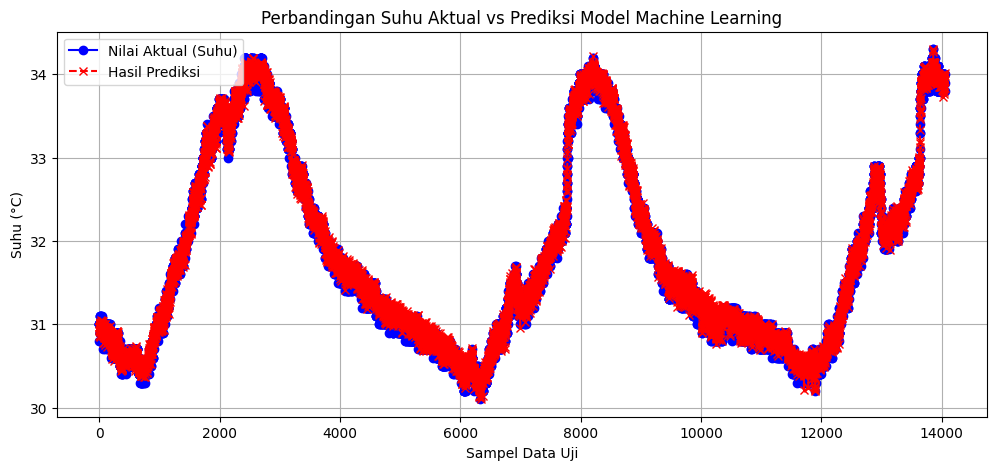

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(y_test.values, label='Nilai Aktual (Suhu)', color='blue', marker='o')
plt.plot(
    y_pred,
    label='Hasil Prediksi',
    color='red',
    linestyle='--',
    marker='x',
)
plt.title('Perbandingan Suhu Aktual vs Prediksi Model Machine Learning')
plt.xlabel('Sampel Data Uji')
plt.ylabel('Suhu (°C)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import numpy as np
import pandas as pd

# Load data
df = pd.read_csv('Data suhu dan Kelembapan.csv')

# 1. Cleaning & Format Datetime
df.columns = df.columns.str.strip()
df['Datetime'] = pd.to_datetime(
    df['Tanggal'] + ' ' + df['Jam'], format='%d/%m/%Y %H:%M:%S', errors='coerce'
)
df = df.dropna(subset=['Datetime'])

for col in ['Suhu (C)', 'Kelembapan %']:
  if df[col].dtype == 'object':
    df[col] = df[col].astype(str).str.replace(',', '.')
  df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.sort_values('Datetime')

# 2. Resampling ke Data Harian (Rata-rata, Min, Max per Hari)
df_daily = (
    df.set_index('Datetime')
    .resample('D')
    .agg({
        'Suhu (C)': ['mean', 'min', 'max'],
        'Kelembapan %': 'mean',
    })
)

# Merapikan nama kolom hasil agregasi
df_daily.columns = [
    'Suhu_Mean',
    'Suhu_Min',
    'Suhu_Max',
    'Kelembapan_Mean',
]
df_daily = df_daily.dropna().reset_index()

# 3. Fitur Lag Harian (Memakai Suhu H-1 dan H-2 untuk Memprediksi Hari Ini)
df_daily['Suhu_H-1'] = df_daily['Suhu_Mean'].shift(1)
df_daily['Suhu_H-2'] = df_daily['Suhu_Mean'].shift(2)
df_daily['Kelembapan_H-1'] = df_daily['Kelembapan_Mean'].shift(1)

# Fitur Kalender
df_daily['DayOfWeek'] = df_daily['Datetime'].dt.dayofweek
df_daily['DayOfYear'] = df_daily['Datetime'].dt.dayofyear

df_model = df_daily.dropna().reset_index(drop=True)
print('--- Data Harian Siap Latih ---')
print(df_model.head())

--- Data Harian Siap Latih ---
    Datetime  Suhu_Mean  Suhu_Min  Suhu_Max  Kelembapan_Mean   Suhu_H-1  \
0 2026-09-09  31.650765      29.4      33.7        63.375826  31.375079   
1 2026-09-10  30.646958      29.8      31.7        66.677471  31.650765   
2 2026-09-17  32.015035      31.5      32.7        64.364800  30.646958   
3 2026-09-18  31.958316      30.4      34.2        63.332243  32.015035   
4 2026-09-19  31.981313      30.4      34.2        64.940530  31.958316   

    Suhu_H-2  Kelembapan_H-1  DayOfWeek  DayOfYear  
0  30.973702       62.282204          2        252  
1  31.375079       63.375826          3        253  
2  31.650765       66.677471          3        260  
3  30.646958       64.364800          4        261  
4  32.015035       63.332243          5        262  


In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Menentukan Fitur (X) dan Target Suhu Rata-Rata Harian (y)
features = [
    'Suhu_H-1',
    'Suhu_H-2',
    'Kelembapan_H-1',
    'DayOfWeek',
    'DayOfYear',
]
target = 'Suhu_Mean'

X = df_model[features]
y = df_model[target]

# Train Model pada Seluruh Data Harian yang Ada
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

last_row = df_model.iloc[-1]

next_day_features = pd.DataFrame([{
    'Suhu_H-1': last_row['Suhu_Mean'],
    'Suhu_H-2': last_row['Suhu_H-1'],
    'Kelembapan_H-1': last_row['Kelembapan_Mean'],
    'DayOfWeek': (last_row['Datetime'].dayofweek + 1) % 7,
    'DayOfYear': last_row['Datetime'].dayofyear + 1,
}])

prediksi_suhu_besok = model.predict(next_day_features)[0]

print(f'\nPrediksi Suhu Rata-rata untuk Hari Berikutnya: {prediksi_suhu_besok:.2f} °C')


Prediksi Suhu Rata-rata untuk Hari Berikutnya: 31.69 °C
